# Figure Platform CPR by Lien Position

This notebook computes monthly CPR for Figure HELOC loans split into:

- `HELOC is first lien`: `loan_lien_position = '1st Lien'`, meaning there is no senior first-lien mortgage ahead of the HELOC.
- `HELOC is subordinate lien`: every other lien position, meaning the HELOC sits behind another mortgage lien.

The BigQuery logic mirrors the prepayment calculation in `lmdv01/dv01_config_platf.py`:

- SMM = `sum(prepay_bal + partial_prepay_bal) / sum(exp_bal)`
- CPR = `100 * (1 - (1 - SMM) ** 12)`

By default it filters the Figure history table to `loan_program = 'FIGURE_HELOC'` so Figure SL/PF/etc. loans do not leak into the HELOC analysis.


In [100]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "lmdv01" / "dv01_config_platf.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not locate LMQR project root from {cwd}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lmdata.lmdb import executeSQLRedshiftDF
from lmdv01 import dv01_utils as utils

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "font.size": 10,
        "legend.fontsize": 9,
        "figure.dpi": 140,
    }
)

LIEN_COLORS = {
    "HELOC is first lien": "#1f77b4",
    "HELOC is subordinate lien": "#ff7f0e",
}
PMMS_COLOR = "#4c4c4c"


def format_month_axis(ax: plt.Axes) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)


def annotate_last_point(ax: plt.Axes, x: pd.Timestamp, y: float, label: str, color: str, x_offset: int = 8) -> None:
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x_offset, 0),
        textcoords="offset points",
        va="center",
        color=color,
        fontsize=9,
        weight="bold",
    )


## Parameters

`factor_date` follows the convention in `dv01_config_platf.py`: it is the month after the DV01 `as_of_date` month. Leave `END_FACTOR_DATE = None` to run through the latest available month.


In [101]:
START_FACTOR_DATE = "2023-08-01"
END_FACTOR_DATE = None  # e.g. "2026-04-01"

LOAN_PROGRAM = "FIGURE_HELOC"
EXCLUDE_POST_D180 = True  # Matches the FIGRE platform stats path in dv01_config_platf.py.

assert START_FACTOR_DATE is None or pd.Timestamp(START_FACTOR_DATE).day == 1
assert END_FACTOR_DATE is None or pd.Timestamp(END_FACTOR_DATE).day == 1


In [102]:
start_filter = (
    f"AND DATE_ADD(DATE_TRUNC(d.as_of_date, MONTH), INTERVAL 1 MONTH) >= DATE('{START_FACTOR_DATE}')"
    if START_FACTOR_DATE
    else ""
)
end_filter = (
    f"AND DATE_ADD(DATE_TRUNC(d.as_of_date, MONTH), INTERVAL 1 MONTH) <= DATE('{END_FACTOR_DATE}')"
    if END_FACTOR_DATE
    else ""
)
loan_program_filter = f"AND d.loan_program = '{LOAN_PROGRAM}'" if LOAN_PROGRAM else ""
post_d180_filter = "AND month_in_d180 < 1" if EXCLUDE_POST_D180 else ""

cpr_sql = f"""
WITH loan_month AS (
  SELECT
    d.dv01_id,
    d.as_of_date,
    DATE_ADD(DATE_TRUNC(d.as_of_date, MONTH), INTERVAL 1 MONTH) AS factor_date,
    CASE
      WHEN s.loan_lien_position = '1st Lien' THEN 'HELOC is first lien'
      ELSE 'HELOC is subordinate lien'
    END AS lien_group,
    s.loan_lien_position,
    d.loan_balance_current,
    CASE WHEN d.loan_balance_current > 0 THEN 1 ELSE 0 END AS non0_loan,
    s.loan_term_orig,
    d.loan_age,
    d.loan_rate_gross_current * 100 AS current_rate,
    COALESCE(
      LAG(d.loan_balance_current, 1) OVER (PARTITION BY d.dv01_id ORDER BY d.as_of_date),
      d.loan_balance_current
    ) AS prevrpb,
    LAG(d.loan_age, 1) OVER (PARTITION BY d.dv01_id ORDER BY d.as_of_date) AS prev_age,
    LAG(d.loan_rate_gross_current * 100, 1) OVER (PARTITION BY d.dv01_id ORDER BY d.as_of_date) AS prev_rate,
    CASE
      WHEN d.loan_status = 'Paid Off' OR d.loan_balance_current <= 0.01 THEN 'PD'
      WHEN d.loan_status IN ('Current', '1 - 29 Days Delinquent') THEN 'C'
      WHEN d.loan_status = '30 - 59 Days Delinquent' THEN 'M30'
      WHEN d.loan_status = '60 - 89 Days Delinquent' THEN 'M60'
      WHEN d.loan_status = '90 - 119 Days Delinquent' THEN 'M90'
      WHEN d.loan_status = '120 - 149 Days Delinquent' THEN 'M120'
      WHEN d.loan_status = '150 - 179 Days Delinquent' THEN 'M150'
      WHEN d.loan_status = 'Foreclosure' THEN 'FCLS'
      WHEN d.loan_status = 'REO' THEN 'REO'
      WHEN d.loan_status IN ('Credit Event', 'Charged Off') THEN 'D'
      WHEN d.loan_status = '>= 180 Days Delinquent' THEN
        CASE
          WHEN GREATEST(DATE_DIFF(d.as_of_date, d.loan_interest_paid_through_date, MONTH) - 1, 0) <= 6 THEN 'M180'
          WHEN GREATEST(DATE_DIFF(d.as_of_date, d.loan_interest_paid_through_date, MONTH) - 1, 0) = 7 THEN 'M210'
          WHEN GREATEST(DATE_DIFF(d.as_of_date, d.loan_interest_paid_through_date, MONTH) - 1, 0) = 8 THEN 'M240'
          ELSE 'M270P'
        END
      ELSE 'X'
    END AS dlq_status
  FROM `dd-client-libremax.libremax.mortgage_history_data_figure_platform` d
  JOIN `dd-client-libremax.libremax.mortgage_static_data_figure_platform` s
    ON s.dv01_id = d.dv01_id
  WHERE 1 = 1
    {loan_program_filter}
    {start_filter}
    {end_filter}
),
with_prev AS (
  SELECT
    *,
    LAG(dlq_status, 1) OVER (PARTITION BY dv01_id ORDER BY as_of_date) AS dlq_status_prev,
    COALESCE(
      SUM(CASE WHEN dlq_status IN ('M180', 'M210', 'M240', 'M270P', 'FCLS', 'REO', 'D') THEN 1 ELSE 0 END)
        OVER (PARTITION BY dv01_id ORDER BY as_of_date ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING),
      0
    ) AS month_in_d180
  FROM loan_month
),
perf AS (
  SELECT
    *,
    CASE
      WHEN prev_age IS NULL OR prev_rate IS NULL OR loan_term_orig <= prev_age OR prevrpb <= 0 THEN NULL
      ELSE
        ((prev_rate / 1200.0) / NULLIF((1 - POWER(1 + prev_rate / 1200.0, -(loan_term_orig - prev_age))), 0)
          * prevrpb - prevrpb * prev_rate / 1200.0)
    END AS prev_exp_prin
  FROM with_prev
),
prepay AS (
  SELECT
    *,
    GREATEST(prevrpb - prev_exp_prin, 0) AS exp_bal,
    CASE
      WHEN prevrpb > 0
        AND loan_balance_current = 0
        AND dlq_status = 'PD'
        AND dlq_status_prev IN ('C', 'M30', 'M60', 'M90')
      THEN GREATEST(prevrpb - prev_exp_prin, 0)
      ELSE 0
    END AS prepay_bal,
    CASE
      WHEN prevrpb > 0
        AND loan_balance_current > 0
        AND dlq_status_prev = 'C'
        AND dlq_status != 'PD'
      THEN GREATEST(prevrpb - loan_balance_current - prev_exp_prin, 0)
      ELSE 0
    END AS partial_prepay_bal
  FROM perf
)
SELECT
  factor_date,
  lien_group,
  COUNT(*) AS loan_months,
  SUM(non0_loan) AS active_loans,
  ROUND(SUM(loan_balance_current), 0) AS current_balance,
  ROUND(SUM(exp_bal), 0) AS exp_bal,
  ROUND(SUM(prepay_bal), 0) AS prepay_bal,
  ROUND(SUM(partial_prepay_bal), 0) AS partial_prepay_bal,
  SAFE_DIVIDE(SUM(prepay_bal + partial_prepay_bal), SUM(exp_bal)) AS smm,
  ROUND(100 * (1 - POWER(1 - SAFE_DIVIDE(SUM(prepay_bal + partial_prepay_bal), SUM(exp_bal)), 12)), 3) AS cpr
FROM prepay
WHERE exp_bal IS NOT NULL
  {post_d180_filter}
GROUP BY factor_date, lien_group
ORDER BY factor_date, lien_group
"""


In [103]:
cpr_by_lien = utils.execute_dv01_big_query(cpr_sql)
cpr_by_lien["factor_date"] = pd.to_datetime(cpr_by_lien["factor_date"])
cpr_by_lien = cpr_by_lien.sort_values(["factor_date", "lien_group"]).reset_index(drop=True)

summary_table = cpr_by_lien.assign(
    factor_month=cpr_by_lien["factor_date"].dt.strftime("%Y-%m"),
    current_balance_bn=cpr_by_lien["current_balance"] / 1e9,
    exp_bal_bn=cpr_by_lien["exp_bal"] / 1e9,
    total_prepay_mm=(cpr_by_lien["prepay_bal"] + cpr_by_lien["partial_prepay_bal"]) / 1e6,
    smm_pct=cpr_by_lien["smm"] * 100,
    cpr_pct=cpr_by_lien["cpr"],
)[[
    "factor_month",
    "lien_group",
    "active_loans",
    "current_balance_bn",
    "exp_bal_bn",
    "total_prepay_mm",
    "smm_pct",
    "cpr_pct",
]]

display(
    summary_table.style.format(
        {
            "active_loans": "{:,.0f}",
            "current_balance_bn": "${:,.2f}bn",
            "exp_bal_bn": "${:,.2f}bn",
            "total_prepay_mm": "${:,.1f}mm",
            "smm_pct": "{:.2f}%",
            "cpr_pct": "{:.1f}%",
        }
    )
)


,factor_month,lien_group,active_loans,current_balance_bn,exp_bal_bn,total_prepay_mm,smm_pct,cpr_pct
0,2023-09,HELOC is first lien,"6,534",$0.38bn,$0.39bn,$12.8mm,3.24%,32.6%
1,2023-09,HELOC is subordinate lien,"72,141",$3.76bn,$3.82bn,$65.6mm,1.72%,18.8%
2,2023-10,HELOC is first lien,"6,772",$0.40bn,$0.41bn,$11.1mm,2.71%,28.0%
3,2023-10,HELOC is subordinate lien,"76,454",$4.00bn,$4.06bn,$63.9mm,1.57%,17.3%
4,2023-11,HELOC is first lien,"7,030",$0.41bn,$0.42bn,$11.1mm,2.64%,27.4%
5,2023-11,HELOC is subordinate lien,"80,227",$4.20bn,$4.26bn,$64.8mm,1.52%,16.8%
6,2023-12,HELOC is first lien,"7,351",$0.43bn,$0.44bn,$10.3mm,2.35%,24.9%
7,2023-12,HELOC is subordinate lien,"84,804",$4.44bn,$4.51bn,$65.7mm,1.46%,16.2%
8,2024-01,HELOC is first lien,"7,611",$0.44bn,$0.45bn,$11.4mm,2.51%,26.3%
9,2024-01,HELOC is subordinate lien,"88,733",$4.65bn,$4.72bn,$68.8mm,1.46%,16.2%


In [104]:
cpr_pivot = cpr_by_lien.pivot(index="factor_date", columns="lien_group", values="cpr").sort_index()
smm_pivot = cpr_by_lien.pivot(index="factor_date", columns="lien_group", values="smm").sort_index()

pmms_sql = f"""
SELECT
    asofmon AS factor_date,
    pmms30
FROM lib.crt_pmms_rate
WHERE asofmon >= '{cpr_pivot.index.min():%Y-%m-%d}'
  AND asofmon <= '{cpr_pivot.index.max():%Y-%m-%d}'
ORDER BY asofmon ASC
"""
pmms_monthly = executeSQLRedshiftDF("padb", pmms_sql)
pmms_monthly["factor_date"] = pd.to_datetime(pmms_monthly["factor_date"])
pmms_monthly["pmms30"] = pd.to_numeric(pmms_monthly["pmms30"], errors="coerce")
pmms_on_plot = pmms_monthly.dropna(subset=["pmms30"]).sort_values("factor_date").reset_index(drop=True)

display(cpr_pivot)


lien_group,HELOC is first lien,HELOC is subordinate lien
factor_date,,
2023-09-01,32.6500,18.7580
2023-10-01,28.0440,17.3320
2023-11-01,27.4400,16.7890
2023-12-01,24.8590,16.1530
2024-01-01,26.3250,16.1700
2024-02-01,28.5410,15.6340
2024-03-01,26.2040,16.0650
2024-04-01,35.2560,18.9410
2024-05-01,32.2910,20.2380


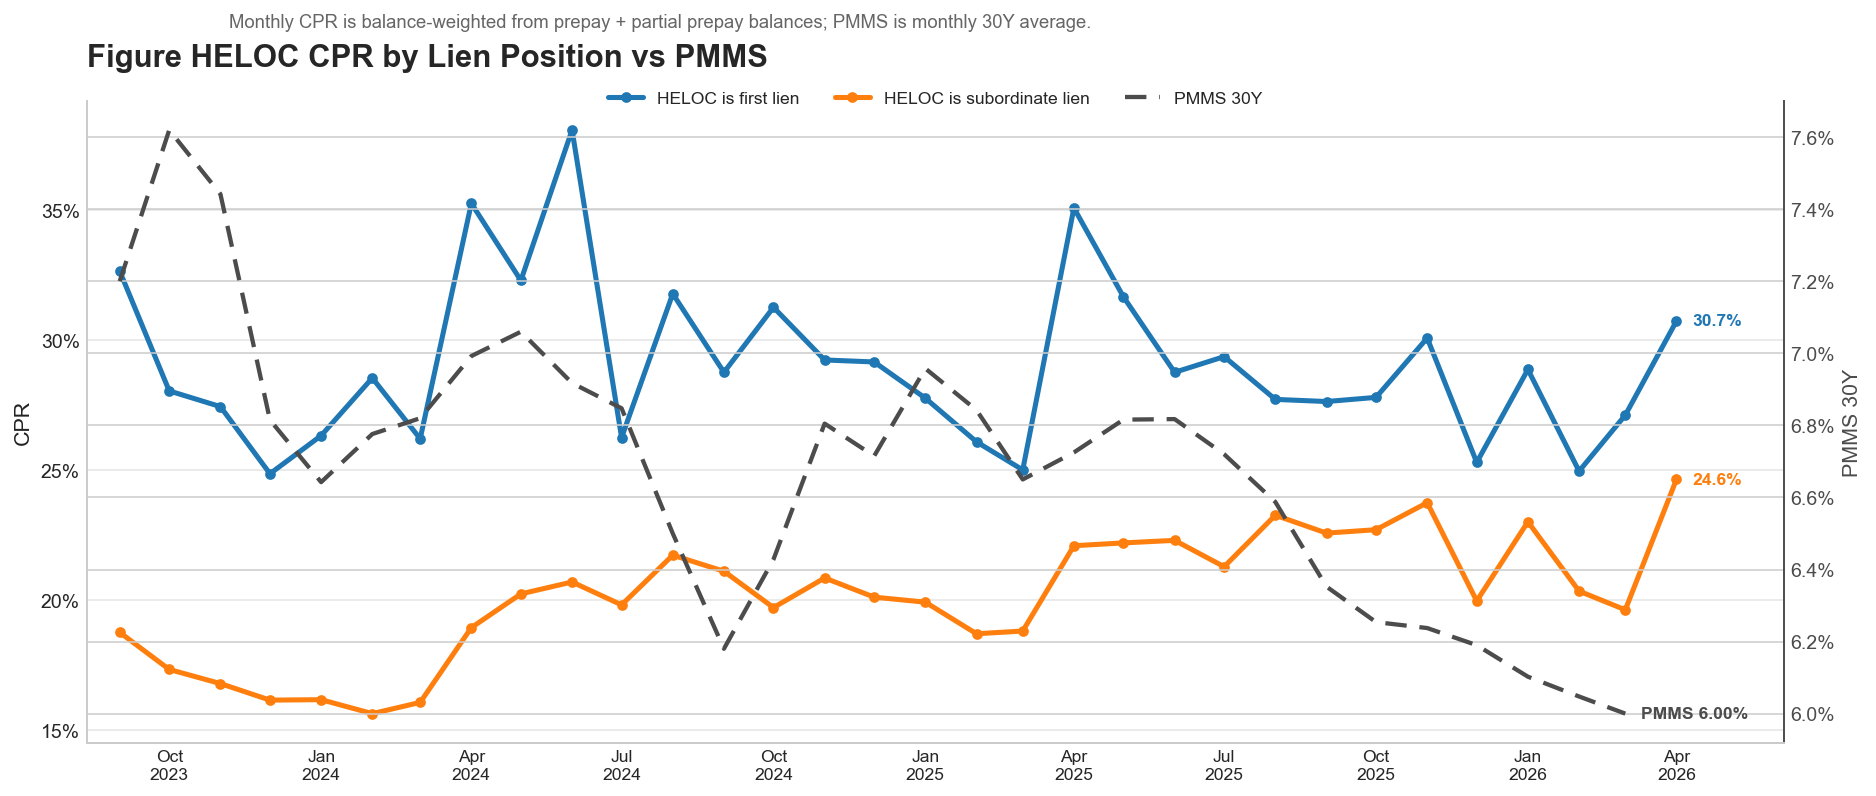

In [105]:
# Keep this cell self-contained enough to rerun after the data cells.
LIEN_COLORS = globals().get(
    "LIEN_COLORS",
    {
        "HELOC is first lien": "#1f77b4",
        "HELOC is subordinate lien": "#ff7f0e",
    },
)
PMMS_COLOR = globals().get("PMMS_COLOR", "#4c4c4c")


def _format_month_axis(ax: plt.Axes) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)


def _annotate_last_point(ax: plt.Axes, x: pd.Timestamp, y: float, label: str, color: str) -> None:
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        color=color,
        fontsize=9,
        weight="bold",
    )


fig, ax = plt.subplots(figsize=(13.5, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for lien_group, color in LIEN_COLORS.items():
    if lien_group in cpr_pivot.columns:
        ax.plot(
            cpr_pivot.index,
            cpr_pivot[lien_group],
            marker="o",
            linewidth=2.6,
            markersize=4.5,
            color=color,
            label=lien_group,
            zorder=3,
        )
        last_y = cpr_pivot[lien_group].dropna().iloc[-1]
        _annotate_last_point(ax, cpr_pivot.index[-1], last_y, f"{last_y:.1f}%", color)

ax_pmms = ax.twinx()
pmms_line = ax_pmms.plot(
    pmms_on_plot["factor_date"],
    pmms_on_plot["pmms30"],
    color=PMMS_COLOR,
    linestyle=(0, (5, 3)),
    linewidth=2.2,
    label="PMMS 30Y",
    zorder=2,
)[0]
if not pmms_on_plot.empty:
    _annotate_last_point(
        ax_pmms,
        pmms_on_plot["factor_date"].iloc[-1],
        pmms_on_plot["pmms30"].iloc[-1],
        f"PMMS {pmms_on_plot['pmms30'].iloc[-1]:.2f}%",
        PMMS_COLOR,
    )

ax.set_title("Figure HELOC CPR by Lien Position vs PMMS", loc="left", pad=18)
fig.text(
    0.125,
    0.91,
    "Monthly CPR is balance-weighted from prepay + partial prepay balances; PMMS is monthly 30Y average.",
    ha="left",
    va="top",
    color="#666666",
    fontsize=9.5,
)
ax.set_xlabel("")
ax.set_ylabel("CPR", color="#222222")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax_pmms.set_ylabel("PMMS 30Y", color=PMMS_COLOR)
ax_pmms.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}%"))
ax_pmms.tick_params(axis="y", colors=PMMS_COLOR)
ax_pmms.spines["right"].set_color(PMMS_COLOR)

_format_month_axis(ax)
ax.set_xlim(cpr_pivot.index.min() - pd.Timedelta(days=20), cpr_pivot.index.max() + pd.Timedelta(days=65))
ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.7)
ax.grid(False, axis="x")

lines, labels = ax.get_legend_handles_labels()
ax.legend(
    lines + [pmms_line],
    labels + [pmms_line.get_label()],
    ncol=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax_pmms.spines["top"].set_visible(False)
ax.spines["left"].set_color("#bbbbbb")
ax.spines["bottom"].set_color("#bbbbbb")

plt.tight_layout(rect=[0, 0, 1, 0.9])


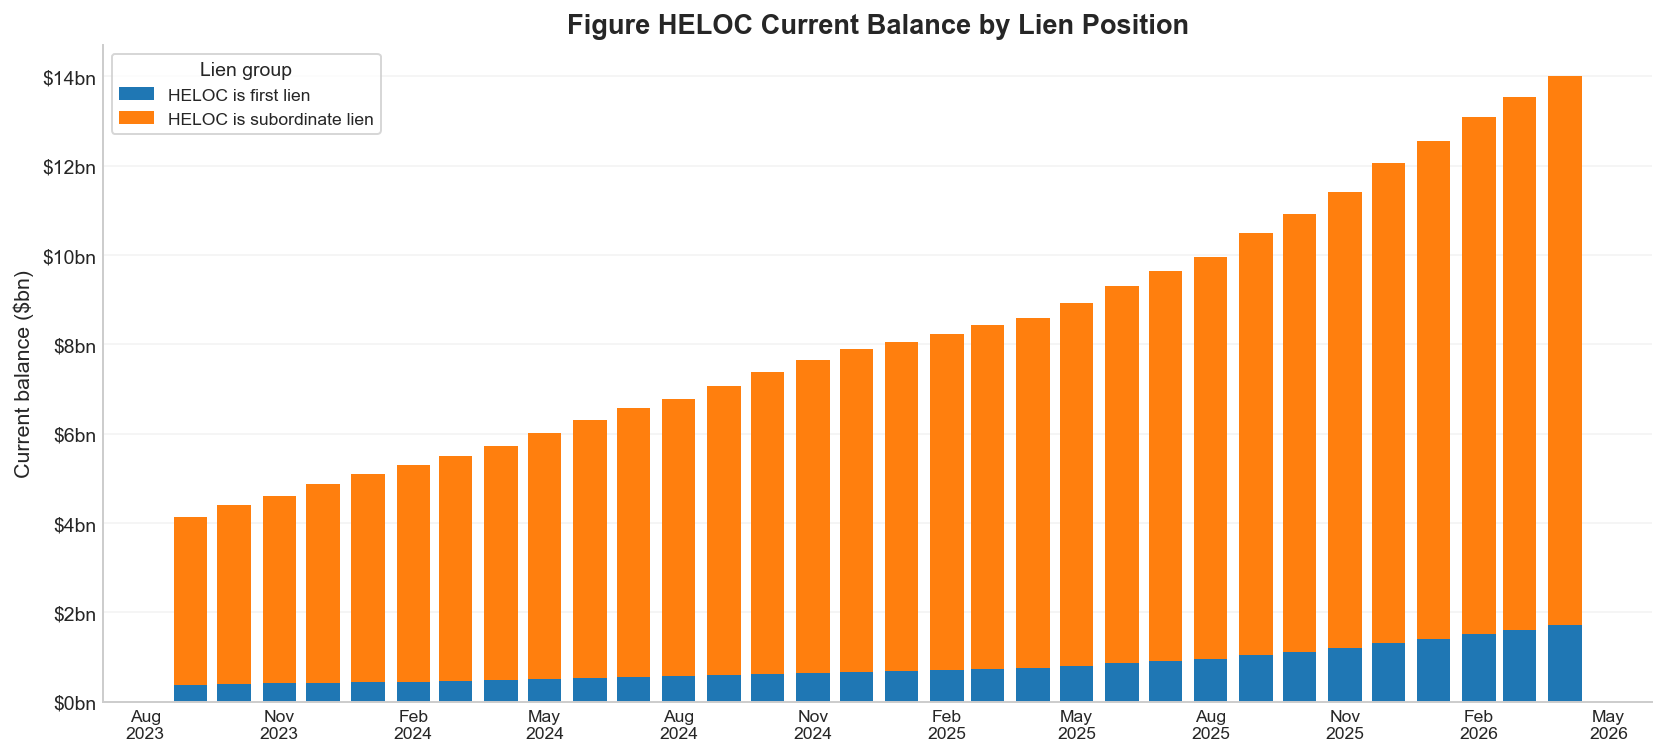

In [106]:
balance_pivot = cpr_by_lien.pivot(index="factor_date", columns="lien_group", values="current_balance").sort_index()
balance_bn = balance_pivot / 1e9

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = pd.Series(0.0, index=balance_bn.index)
for lien_group, color in LIEN_COLORS.items():
    if lien_group in balance_bn.columns:
        ax.bar(
            balance_bn.index,
            balance_bn[lien_group],
            bottom=bottom,
            width=23,
            color=color,
            label=lien_group,
        )
        bottom = bottom + balance_bn[lien_group].fillna(0)

ax.set_title("Figure HELOC Current Balance by Lien Position", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Current balance ($bn)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}bn"))
format_month_axis(ax)
ax.grid(True, axis="y", alpha=0.25)
ax.grid(False, axis="x")
ax.legend(title="Lien group", frameon=True, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()


## Latest-Snapshot Distribution Comparison

The CPR gap can be driven by collateral mix, not only lien position itself. This section pulls the latest available Figure HELOC month and compares rate, FICO, CLTV/LTV, age, balance, and utilization for `HELOC is first lien` versus `HELOC is subordinate lien`.

In [107]:
distribution_factor_date = cpr_by_lien["factor_date"].max()

distribution_sql = f"""
WITH base AS (
  SELECT
    DATE_ADD(DATE_TRUNC(d.as_of_date, MONTH), INTERVAL 1 MONTH) AS factor_date,
    CASE
      WHEN s.loan_lien_position = '1st Lien' THEN 'HELOC is first lien'
      ELSE 'HELOC is subordinate lien'
    END AS lien_group,
    d.loan_rate_gross_current * 100 AS loan_rate_pct,
    COALESCE(d.fico_updated, s.fico_orig) AS fico,
    s.fico_orig AS orig_fico,
    CASE
      WHEN d.line_of_credit_combined_loan_to_value IS NULL THEN NULL
      WHEN d.line_of_credit_combined_loan_to_value <= 2 THEN d.line_of_credit_combined_loan_to_value * 100
      ELSE d.line_of_credit_combined_loan_to_value
    END AS raw_current_cltv_pct,
    CASE
      WHEN d.asset_combined_loan_to_value IS NULL THEN NULL
      WHEN d.asset_combined_loan_to_value <= 2 THEN d.asset_combined_loan_to_value * 100
      ELSE d.asset_combined_loan_to_value
    END AS raw_current_asset_cltv_pct,
    CASE
      WHEN d.asset_loan_to_value IS NULL THEN NULL
      WHEN d.asset_loan_to_value <= 2 THEN d.asset_loan_to_value * 100
      ELSE d.asset_loan_to_value
    END AS raw_current_ltv_pct,
    NULL AS current_cltv_pct,
    NULL AS current_ltv_pct,
    (s.asset_loan_to_value_orig + d.line_of_credit_combined_loan_to_value - s.line_of_credit_amount_orig / s.asset_appraised_value_orig) * 100.0 AS orig_cltv_pct,
    s.asset_loan_to_value_orig * 100.0 AS orig_ltv_pct,
    d.loan_age,
    d.loan_balance_current AS current_balance,
    d.line_of_credit_amount,
    CASE
      WHEN d.line_of_credit_utilization_percent IS NULL THEN NULL
      WHEN d.line_of_credit_utilization_percent <= 2 THEN d.line_of_credit_utilization_percent * 100
      ELSE d.line_of_credit_utilization_percent
    END AS loc_utilization_pct
  FROM `dd-client-libremax.libremax.mortgage_history_data_figure_platform` d
  JOIN `dd-client-libremax.libremax.mortgage_static_data_figure_platform` s
    ON s.dv01_id = d.dv01_id
  WHERE d.loan_program = '{LOAN_PROGRAM}'
)
SELECT *
FROM base
WHERE factor_date = DATE('{distribution_factor_date:%Y-%m-%d}')
  AND current_balance > 0
ORDER BY lien_group, current_balance DESC
"""

distribution_data = utils.execute_dv01_big_query(distribution_sql)
distribution_data["factor_date"] = pd.to_datetime(distribution_data["factor_date"])
distribution_data["current_balance_k"] = distribution_data["current_balance"] / 1_000
distribution_data["line_of_credit_amount_k"] = distribution_data["line_of_credit_amount"] / 1_000

# Match dv01_config_platf.py for standardized Figure output: orig_ltv/orig_cltv are exposed;
# upd_ltv/upd_cltv are intentionally null. Keep raw current feed fields separately for diagnostics.
for column_name in [
    "orig_cltv_pct",
    "orig_ltv_pct",
    "raw_current_cltv_pct",
    "raw_current_asset_cltv_pct",
    "raw_current_ltv_pct",
]:
    distribution_data[column_name] = distribution_data[column_name].where(distribution_data[column_name].between(0, 200))

distribution_data["cltv_pct"] = distribution_data["orig_cltv_pct"]
distribution_data["ltv_pct"] = distribution_data["orig_ltv_pct"]

cltv_coverage = distribution_data.groupby("lien_group")[[
    "cltv_pct",
    "raw_current_cltv_pct",
    "raw_current_asset_cltv_pct",
    "raw_current_ltv_pct",
]].agg(lambda x: x.notna().mean())
distribution_data.shape, cltv_coverage


((267501, 20),
                            cltv_pct  raw_current_cltv_pct  \
 lien_group                                                  
 HELOC is first lien          0.9996                1.0000   
 HELOC is subordinate lien    1.0000                1.0000   
 
                            raw_current_asset_cltv_pct  raw_current_ltv_pct  
 lien_group                                                                  
 HELOC is first lien                            0.0000               1.0000  
 HELOC is subordinate lien                      0.0000               1.0000  )

In [108]:
distribution_metrics = {
    "Loan rate (%)": "loan_rate_pct",
    "FICO": "fico",
    "Orig CLTV (%)": "cltv_pct",
    "Orig LTV (%)": "ltv_pct",
    "Raw current LOC CLTV (%)": "raw_current_cltv_pct",
    "Raw current asset CLTV (%)": "raw_current_asset_cltv_pct",
    "Raw current LTV (%)": "raw_current_ltv_pct",
    "Loan age (months)": "loan_age",
    "Current balance ($000s)": "current_balance_k",
    "Line amount ($000s)": "line_of_credit_amount_k",
    "LOC utilization (%)": "loc_utilization_pct",
}


def weighted_quantile(values: pd.Series, quantiles: list[float], weights: pd.Series) -> np.ndarray:
    clean = pd.DataFrame({"value": values, "weight": weights}).dropna()
    clean = clean[clean["weight"] > 0]
    if clean.empty:
        return np.full(len(quantiles), np.nan)
    clean = clean.sort_values("value")
    cumulative_weight = clean["weight"].cumsum() - 0.5 * clean["weight"]
    cumulative_weight = cumulative_weight / clean["weight"].sum()
    return np.interp(quantiles, cumulative_weight, clean["value"])


summary_rows = []
for lien_group, group_data in distribution_data.groupby("lien_group"):
    weights = group_data["current_balance"]
    for metric_name, column_name in distribution_metrics.items():
        values = pd.to_numeric(group_data[column_name], errors="coerce")
        valid = values.notna() & weights.notna() & (weights > 0)
        if not valid.any():
            continue
        q10, q25, q50, q75, q90 = weighted_quantile(values[valid], [0.10, 0.25, 0.50, 0.75, 0.90], weights[valid])
        summary_rows.append(
            {
                "metric": metric_name,
                "lien_group": lien_group,
                "loan_count": int(valid.sum()),
                "balance_bn": weights[valid].sum() / 1e9,
                "weighted_avg": np.average(values[valid], weights=weights[valid]),
                "w_p10": q10,
                "w_p25": q25,
                "w_median": q50,
                "w_p75": q75,
                "w_p90": q90,
            }
        )

distribution_summary = pd.DataFrame(summary_rows)

display(
    distribution_summary.style.format(
        {
            "loan_count": "{:,.0f}",
            "balance_bn": "${:,.2f}bn",
            "weighted_avg": "{:,.2f}",
            "w_p10": "{:,.2f}",
            "w_p25": "{:,.2f}",
            "w_median": "{:,.2f}",
            "w_p75": "{:,.2f}",
            "w_p90": "{:,.2f}",
        }
    )
)


,metric,lien_group,loan_count,balance_bn,weighted_avg,w_p10,w_p25,w_median,w_p75,w_p90
0,Loan rate (%),HELOC is first lien,"25,496",$1.96bn,8.19,6.70,7.25,7.95,8.85,10.20
1,FICO,HELOC is first lien,"25,496",$1.96bn,747.43,673.00,702.00,746.00,794.00,825.00
2,Orig CLTV (%),HELOC is first lien,"25,486",$1.96bn,43.23,13.12,23.49,41.21,63.67,78.05
3,Orig LTV (%),HELOC is first lien,"25,496",$1.96bn,42.78,12.95,23.31,40.82,62.65,77.34
4,Raw current LOC CLTV (%),HELOC is first lien,"25,496",$1.96bn,45.18,15.62,25.80,43.72,65.37,78.87
5,Raw current LTV (%),HELOC is first lien,"25,496",$1.96bn,41.66,12.02,22.20,39.22,61.51,76.37
6,Loan age (months),HELOC is first lien,"25,496",$1.96bn,11.89,0.00,2.00,6.00,15.00,34.00
7,Current balance ($000s),HELOC is first lien,"25,496",$1.96bn,170.12,47.21,79.28,133.10,236.76,361.68
8,Line amount ($000s),HELOC is first lien,"25,496",$1.96bn,185.42,56.24,93.19,152.99,255.03,386.71
9,LOC utilization (%),HELOC is first lien,"25,496",$1.96bn,95.22,87.48,97.62,99.29,99.70,100.00


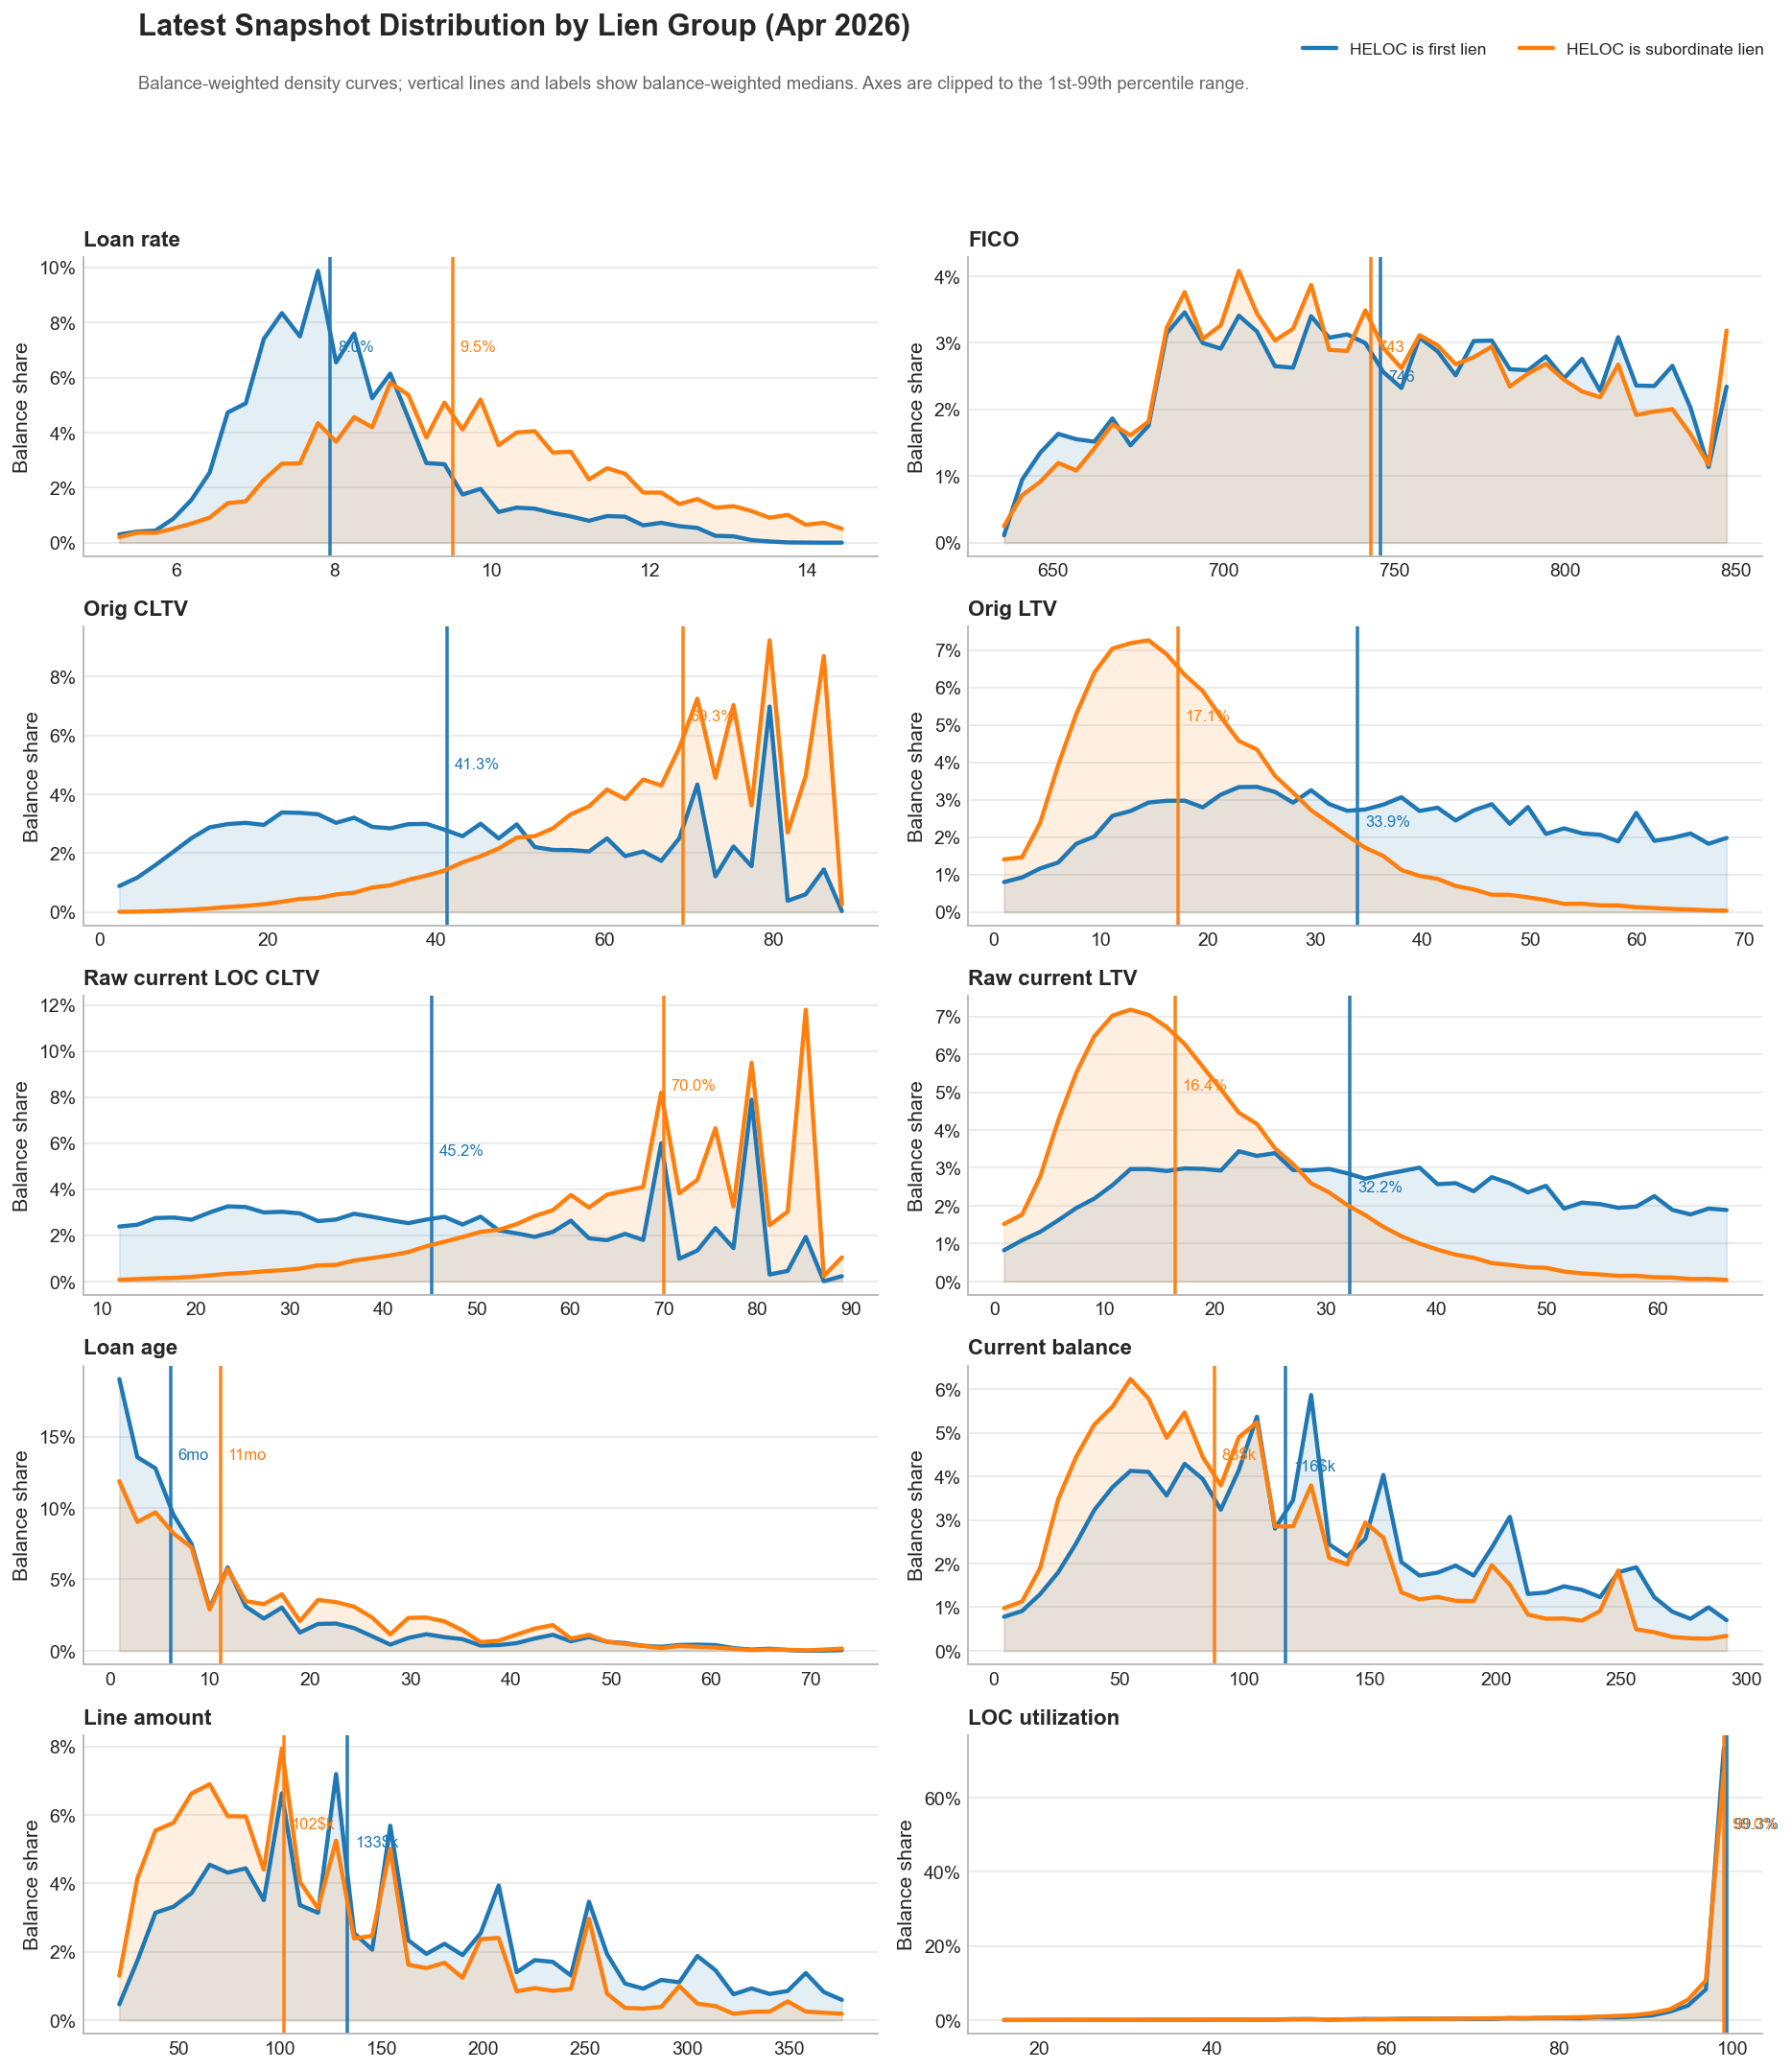

In [109]:
plot_metrics = [
    ("Loan rate", "loan_rate_pct", "%"),
    ("FICO", "fico", ""),
    ("Orig CLTV", "cltv_pct", "%"),
    ("Orig LTV", "ltv_pct", "%"),
    ("Raw current LOC CLTV", "raw_current_cltv_pct", "%"),
    ("Raw current asset CLTV", "raw_current_asset_cltv_pct", "%"),
    ("Raw current LTV", "raw_current_ltv_pct", "%"),
    ("Loan age", "loan_age", "mo"),
    ("Current balance", "current_balance_k", "$k"),
    ("Line amount", "line_of_credit_amount_k", "$k"),
    ("LOC utilization", "loc_utilization_pct", "%"),
]

available_plot_metrics = []
for metric_name, column_name, unit in plot_metrics:
    values = pd.to_numeric(distribution_data[column_name], errors="coerce")
    if values.notna().sum() > 0 and values.nunique(dropna=True) > 1:
        available_plot_metrics.append((metric_name, column_name, unit))

ncols = 2
nrows = int(np.ceil(len(available_plot_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 3.1 * nrows), squeeze=False)
fig.patch.set_facecolor("white")

legend_handles: list[plt.Line2D] = []
legend_labels: list[str] = []

for ax, (metric_name, column_name, unit) in zip(axes.ravel(), available_plot_metrics):
    metric_values = pd.to_numeric(distribution_data[column_name], errors="coerce")
    p01, p99 = metric_values.quantile([0.01, 0.99])
    if pd.isna(p01) or pd.isna(p99) or p01 == p99:
        ax.set_visible(False)
        continue

    bins = np.linspace(p01, p99, 42)
    centers = (bins[:-1] + bins[1:]) / 2
    max_density = 0.0

    for lien_group, color in LIEN_COLORS.items():
        group_data = distribution_data[distribution_data["lien_group"] == lien_group]
        values = pd.to_numeric(group_data[column_name], errors="coerce")
        weights = pd.to_numeric(group_data["current_balance"], errors="coerce")
        valid = values.notna() & weights.notna() & (weights > 0) & values.between(p01, p99)
        if not valid.any():
            continue

        hist, _ = np.histogram(values[valid], bins=bins, weights=weights[valid])
        density = hist / hist.sum() if hist.sum() > 0 else hist
        max_density = max(max_density, float(np.nanmax(density)))
        line = ax.plot(centers, density, color=color, linewidth=2.25, label=lien_group)[0]
        ax.fill_between(centers, density, color=color, alpha=0.12)

        median = weighted_quantile(values[valid], [0.50], weights[valid])[0]
        ax.axvline(median, color=color, linewidth=1.8, alpha=0.95)
        ax.annotate(
            f"{median:,.0f}{unit}" if unit != "%" else f"{median:,.1f}%",
            xy=(median, max_density * 0.72 if max_density else 0),
            xytext=(4, 0),
            textcoords="offset points",
            color=color,
            fontsize=8.5,
            va="center",
        )

        if lien_group not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(lien_group)

    ax.set_title(metric_name, loc="left", fontsize=11.5, weight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
    ax.set_ylabel("Balance share")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.65)
    ax.grid(False, axis="x")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#bbbbbb")
    ax.spines["bottom"].set_color("#bbbbbb")

for ax in axes.ravel()[len(available_plot_metrics):]:
    ax.set_visible(False)

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.985, 0.985),
)
fig.suptitle(
    f"Latest Snapshot Distribution by Lien Group ({distribution_factor_date:%b %Y})",
    x=0.08,
    y=0.992,
    ha="left",
    fontsize=16,
    weight="bold",
)
fig.text(
    0.08,
    0.962,
    "Balance-weighted density curves; vertical lines and labels show balance-weighted medians. Axes are clipped to the 1st-99th percentile range.",
    ha="left",
    va="top",
    color="#666666",
    fontsize=9.5,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])


In [110]:
# Optional: uncomment if you want to export the notebook tables.
# output_path = PROJECT_ROOT / "lmdv01" / "figure_cpr_by_lien.xlsx"
#
# with pd.ExcelWriter(output_path) as writer:
#     summary_table.to_excel(writer, sheet_name="formatted_summary", index=False)
#     cpr_by_lien.to_excel(writer, sheet_name="monthly_cpr", index=False)
#     cpr_pivot.to_excel(writer, sheet_name="cpr_pivot")
#     smm_pivot.to_excel(writer, sheet_name="smm_pivot")
#     pmms_on_plot.to_excel(writer, sheet_name="pmms", index=False)
#     if "distribution_summary" in globals():
#         distribution_summary.to_excel(writer, sheet_name="distribution_summary", index=False)
#     if "distribution_data" in globals():
#         distribution_data.to_excel(writer, sheet_name="distribution_raw", index=False)
#
# output_path
